(1856, 2880)


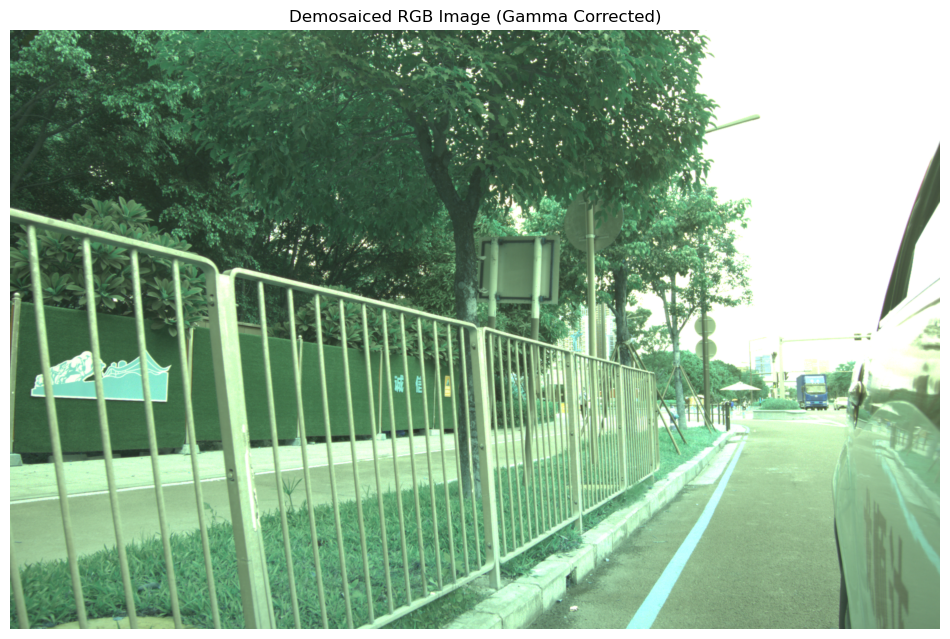

Original RGB range: [524, 65535]
Normalized RGB range: [0.008, 1.000]


In [9]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

img_path_str = '/cifs/Shares/Raw_Bayer_Datasets/ROD/raw/val/day-00001.raw'

BIT8, BIT16 = 2**8, 2**16
# img_shape=(1, 1, 1856, 2880) 
# read_type=np.uint8
img = np.fromfile(img_path_str, dtype=np.uint8)
img = img.astype(np.float32)
img = img[0::3] + img[1::3] * BIT8 + img[2::3] * BIT16
img = img.reshape((1856, 2880))
print(img.shape)

# Normalize to 16-bit for OpenCV
img_16 = np.clip(img, 0, 65535).astype(np.uint16)

# Demosaic using OpenCV (assuming Bayer RGGB pattern, adjust if needed)
rgb = cv2.cvtColor(img_16, cv2.COLOR_BAYER_RG2RGB)

# Normalize to 0-1 range for proper display
rgb_normalized = rgb.astype(np.float32) / 65535.0

# Optional: Apply gamma correction for better visualization
rgb_gamma = np.power(rgb_normalized, 1/2.2)

plt.figure(figsize=(12, 8))
plt.imshow(rgb_gamma)
plt.title('Demosaiced RGB Image (Gamma Corrected)')
plt.axis('off')
plt.show()

# Also show some statistics
print(f"Original RGB range: [{rgb.min()}, {rgb.max()}]")
print(f"Normalized RGB range: [{rgb_normalized.min():.3f}, {rgb_normalized.max():.3f}]")

from pathlib import Path
img_path = Path(img_path_str)
suffix = img_path.suffix.lower()
RAW_EXT = {'.nef', '.cr2', '.arw', '.dng', '.rw2'}
ROD_EXT = {'.raw'}  
# add other raw extensions if needed